In [5]:
!pip3 install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 5.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats

In [9]:
df = pd.read_csv('/Users/chloeshin/Downloads/Cleaned_data.csv', encoding = 'utf-8')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6378 entries, 0 to 6377
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6378 non-null   int64 
 1   Attendance                  6378 non-null   int64 
 2   Parental_Involvement        6378 non-null   object
 3   Access_to_Resources         6378 non-null   object
 4   Extracurricular_Activities  6378 non-null   object
 5   Sleep_Hours                 6378 non-null   int64 
 6   Previous_Scores             6378 non-null   int64 
 7   Motivation_Level            6378 non-null   object
 8   Internet_Access             6378 non-null   object
 9   Tutoring_Sessions           6378 non-null   int64 
 10  Family_Income               6378 non-null   object
 11  Teacher_Quality             6378 non-null   object
 12  School_Type                 6378 non-null   object
 13  Peer_Influence              6378 non-null   obje

In [23]:
cont = df[['Hours_Studied', 'Attendance', 'Extracurricular_Activities', 'Sleep_Hours', 'Physical_Activity', 'Score_Diff']].copy() 

In [24]:
uncont = df[['Family_Income', 'Access_to_Resources', 'Parental_Education_Level', 'Peer_Influence', 'Parental_Involvement', 'Score_Diff']].copy()

## Controllable Variables

In [25]:
cont['Extracurricular_Activities'] = cont['Extracurricular_Activities'].astype('category')
cont['Physical_Activity'] = cont['Physical_Activity'].astype('category')

cont.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6378 entries, 0 to 6377
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Hours_Studied               6378 non-null   int64   
 1   Attendance                  6378 non-null   int64   
 2   Extracurricular_Activities  6378 non-null   category
 3   Sleep_Hours                 6378 non-null   int64   
 4   Physical_Activity           6378 non-null   category
 5   Score_Diff                  6378 non-null   int64   
dtypes: category(2), int64(4)
memory usage: 212.4 KB


In [28]:
cont_model = smf.ols('Score_Diff ~ Hours_Studied + Attendance + Extracurricular_Activities + Sleep_Hours + Physical_Activity', data = cont).fit()

cont_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Score_Diff   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     29.28
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.13e-55
Time:                        15:18:31   Log-Likelihood:                -25851.
No. Observations:                6378   AIC:                         5.172e+04
Df Residuals:                    6367   BIC:                         5.180e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -37.5307      2.656    -14.128      0.000     -42.738     -32.323
Extracurricular_Activities[T.Yes]     0.4504      0.356      1.265      0.206      -0.248       1.148
Physical_Activity[T.1]                5.5462      2.215      2.504      0.012       1.205       9.888
Physical_Activity[T.2]                5.6627      2.132      2.657      0.008       1.484       9.841
Physical_Activity[T.3]                5.2299      2.121      2.466      0.014       1.072       9.387
Physical_Activity[T.4]                5.8530      2.132      2.745      0.006       1.673      10.033
Physical_Activity[T.5]                6.5275      2.232      2.925      0.003       2.152      10.903
Physical_Activity[T.6]                4.9331      3.270      1.509      0.131      -1.477      11.344
Hours_Studied                         0.2378      0.029      8.148      0.000       0.181       0.295
Attendance                            0.2210      0.015     14.610      0.000       0.191       0.251
Sleep_Hours                           0.2097      0.119      1.762      0.078      -0.024       0.443
==============================================================================
Omnibus:                     1557.867   Durbin-Watson:                   2.042
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              275.155
Skew:                           0.048   Prob(JB):                     1.78e-60
Kurtosis:                       1.987   Cond. No.                     2.73e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.73e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
anova = sm.stats.anova_lm(cont_model, typ = 2)
anova

,sum_sq,df,F,PR(>F)
Extracurricular_Activities,3.111694e+02,1.0,1.600478,2.058818e-01
Physical_Activity,2.108498e+03,6.0,1.807485,9.347881e-02
Hours_Studied,1.290761e+04,1.0,66.389403,4.417555e-16
Attendance,4.149918e+04,1.0,213.448113,1.421462e-47
Sleep_Hours,6.033574e+02,1.0,3.103326,7.818048e-02
Residual,1.237890e+06,6367.0,NaN,NaN


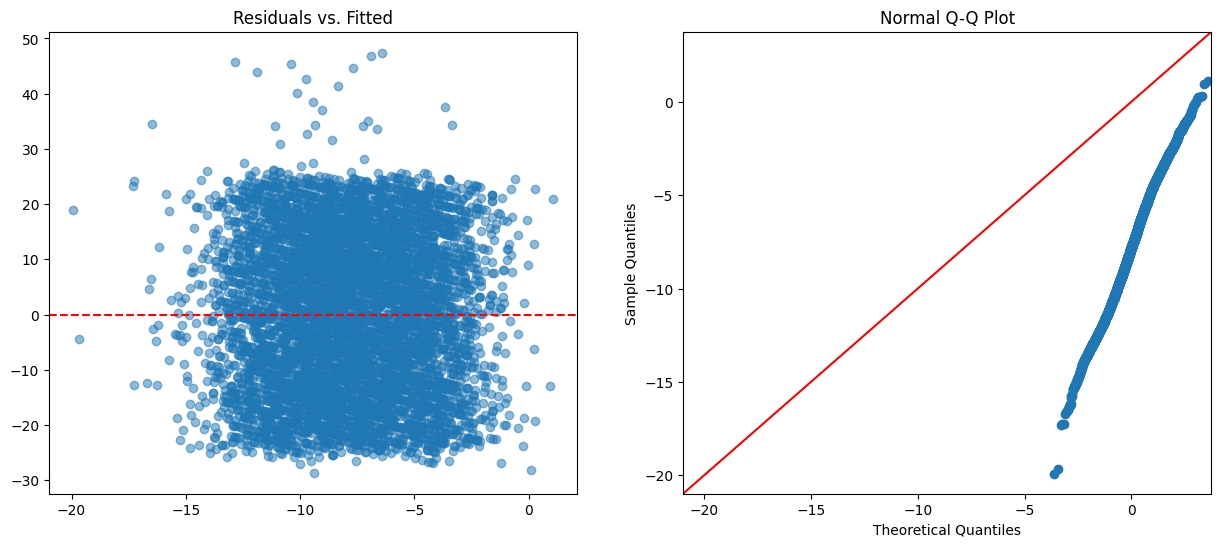

In [31]:
cont_residuals = cont_model.resid
cont_fitted = cont_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize = (15, 6))

axes[0].scatter(cont_fitted, cont_residuals, alpha=0.5)
axes[0].axhline(y=0, color = 'red', linestyle = '--')
axes[0].set_title('Residuals vs. Fitted')

sm.qqplot(cont_fitted, line = '45', ax = axes[1])
axes[1].set_title('Normal Q-Q Plot')

plt.show()

In [33]:
grid = pd.MultiIndex.from_product(
    [cont['Hours_Studied'].unique(), 
     cont['Attendance'].unique(), 
     cont['Extracurricular_Activities'].unique(),
     cont['Sleep_Hours'].unique(),
     cont['Physical_Activity'].unique()],
    names=['Hours_Studied', 'Attendance', 'Extracurricular_Activities', 'Sleep_Hours', 'Physical_Activity']
).to_frame(index=False)

grid['Predicted_Score_Diff'] = cont_model.predict(grid)

grid_sorted = grid.sort_values(by='Predicted_Score_Diff', ascending = False)

print("Predicted Score Improvements:\n")
print(grid_sorted.head(10).to_string(index = False))

Predicted Score Improvements:

 Hours_Studied  Attendance Extracurricular_Activities  Sleep_Hours Physical_Activity  Predicted_Score_Diff
            44         100                        Yes           10                 5              4.106179
            44         100                        Yes            9                 5              3.896504
            44          99                        Yes           10                 5              3.885194
            43         100                        Yes           10                 5              3.868365
            44         100                        Yes            8                 5              3.686829
            44          99                        Yes            9                 5              3.675519
            44          98                        Yes           10                 5              3.664210
            43         100                        Yes            9                 5              3.658690
      

## Uncontrollable Variables

In [49]:
uncont.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6378 entries, 0 to 6377
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Family_Income             6378 non-null   object
 1   Access_to_Resources       6378 non-null   object
 2   Parental_Education_Level  6378 non-null   object
 3   Peer_Influence            6378 non-null   object
 4   Parental_Involvement      6378 non-null   object
 5   Score_Diff                6378 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 299.1+ KB


In [54]:
uncont_model = smf.ols('Score_Diff ~ C(Family_Income) + C(Access_to_Resources) + C(Parental_Education_Level) + C(Peer_Influence) + C(Parental_Involvement)', data = uncont).fit()

uncont_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Score_Diff   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.062
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           3.92e-11
Time:                        15:51:22   Log-Likelihood:                -25959.
No. Observations:                6378   AIC:                         5.194e+04
Df Residuals:                    6367   BIC:                         5.201e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                      -5.2034      0.711     -7.315      0.000      -6.598      -3.809
C(Family_Income)[T.Low]                        -1.6914      0.492     -3.441      0.001      -2.655      -0.728
C(Family_Income)[T.Medium]                     -1.1634      0.492     -2.365      0.018      -2.128      -0.199
C(Access_to_Resources)[T.Low]                  -0.9005      0.514     -1.752      0.080      -1.908       0.107
C(Access_to_Resources)[T.Medium]               -0.7753      0.411     -1.887      0.059      -1.581       0.030
C(Parental_Education_Level)[T.High School]     -1.2404      0.410     -3.029      0.002      -2.043      -0.438
C(Parental_Education_Level)[T.Postgraduate]     0.1248      0.511      0.244      0.807      -0.877       1.127
C(Peer_Influence)[T.Neutral]                    0.4688      0.482      0.973      0.331      -0.476       1.414
C(Peer_Influence)[T.Positive]                   1.6355      0.480      3.408      0.001       0.695       2.576
C(Parental_Involvement)[T.Low]                 -2.6256      0.516     -5.091      0.000      -3.637      -1.615
C(Parental_Involvement)[T.Medium]              -1.1885      0.414     -2.869      0.004      -2.001      -0.376
==============================================================================
Omnibus:                     1275.783   Durbin-Watson:                   2.028
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              254.613
Skew:                           0.039   Prob(JB):                     5.15e-56
Kurtosis:                       2.024   Cond. No.                         8.38
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [55]:
anova2 = sm.stats.anova_lm(uncont_model, typ = 2)
anova2

,sum_sq,df,F,PR(>F)
C(Family_Income),2.382132e+03,2.0,5.921787,0.002695
C(Access_to_Resources),8.905000e+02,2.0,2.213711,0.109378
C(Parental_Education_Level),2.662054e+03,2.0,6.617649,0.001346
C(Peer_Influence),2.895287e+03,2.0,7.197448,0.000755
C(Parental_Involvement),5.230720e+03,2.0,13.003144,0.000002
Residual,1.280613e+06,6367.0,NaN,NaN


In [65]:
grid_uncont = pd.MultiIndex.from_product(
    [uncont['Family_Income'].unique(), 
     uncont['Access_to_Resources'].unique(), 
     uncont['Parental_Education_Level'].unique(),
     uncont['Peer_Influence'].unique(),
     uncont['Parental_Involvement'].unique()],
    names = ['Family_Income', 'Access_to_Resources', 'Parental_Education_Level', 'Peer_Influence', 'Parental_Involvement']
).to_frame(index = False)

grid_uncont['Predicted_Score_Diff'] = uncont_model.predict(grid_uncont)

grid_sorted_uncont = grid_uncont.sort_values(by ='Predicted_Score_Diff', ascending = False)

print("Predicted Score Improvements:\n")
print(grid_sorted_uncont.head(10).to_string(index = False))

Predicted Score Improvements:

Family_Income Access_to_Resources Parental_Education_Level Peer_Influence Parental_Involvement  Predicted_Score_Diff
         High                High             Postgraduate       Positive                 High             -3.443049
         High                High                  College       Positive                 High             -3.567896
         High              Medium             Postgraduate       Positive                 High             -4.218312
         High              Medium                  College       Positive                 High             -4.343159
         High                 Low             Postgraduate       Positive                 High             -4.343589
         High                 Low                  College       Positive                 High             -4.468436
       Medium                High             Postgraduate       Positive                 High             -4.606410
         High                High